# Proyek Analisis Data: Bike Sharing Dataset

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren jumlah penyewaan sepeda per bulan selama tahun 2012 dibandingkan dengan tahun 2011, dan pada bulan apa terjadi kenaikan tertinggi?
- **Pertanyaan 2:** Berapakah rata-rata penurunan jumlah penyewa sepeda saat kondisi cuaca buruk (weathersit 3 & 4) dibandingkan cuaca cerah di hari kerja selama seluruh periode data?
- **Pertanyaan 3:** Pada jam berapa puncak penyewaan terjadi pada hari kerja (working day) dibandingkan akhir pekan, dan apakah polanya konsisten di setiap musim?
- **Pertanyaan 4:** Bagaimana dampak hari libur nasional (holiday) terhadap total distribusi peminjaman dibandingkan hari biasa?
- **Pertanyaan 5:** Berdasarkan dataset hour.csv, bagaimana segmentasi hari berdasarkan intensitas penggunaan (Monetary/Volume), seberapa sering hari tersebut digunakan dalam puncak musim (Frequency), dan kapan terakhir kali terjadi lonjakan penyewaan (Recency)?


## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df day.csv

In [2]:
day_df = pd.read_csv('day.csv')
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


**Insight:**
Dataset day.csv berisi data historis harian mengenai penyewaan sepeda dari sistem Capital Bikeshare di Washington D.C. Dataset ini berisi data per hari yang terdiri dari 731 data. Dataset ini memisahkan antara pengguna casual dan registered (pengguna rutin/komuter) yang biasanya memiliki pola perilaku berbeda terhadap cuaca atau hari kerja.<p>

Berikut rincian kolom-kolomnya:
- **Instant:** merupakan indeks catatan atau nomor urut baris.
- **dteday:** berisi tanggal pencatatan data.
- **season:** berisi musim saat tanggal pencatatan, dengan rincian musimnya:
  - 1: Musim Dingin (Winter)
  - 2: Musim Semi (Spring)
  - 3: Musim Panas (Summer)
  - 4: Musim Gugur (Fall)
- **yr:** berisi tahun saat tanggal pencatatan.
- **mnth:** berisi bulan saat tanggal pencatatan.
- **holiday:** berisi apakah hari tersebut merupakan hari libur atau tidak saat tanggal pencatatan (berdasarkan jadwal hari libur resmi).
- **weekday:** berisi hari dalam seminggu (0 hingga 6).
- **workingday:** berisi apakah hari saat tanggal pencatatan merupakan hari kerja atau weekend/hari libur, dengan nilai:
  - 1: hari kerja
  - 0: hari libur/weekend
- **weahersit:** berisi situasi cuaca saat tanggal pencatatan:
  - 1: Cerah/Sedikit Berawan (Clear/Partly Cloudy)
  - 2: Kabut/Berawan (Misty/Cloudy)
  - 3: Salju ringan/Hujan ringan (Light Snow/Rain)
  - 4: Hujan lebat/Badai (Heavy Rain/Snow)
- **temp:** berisi suhu saat tanggal pencatatan yang sudah dinormalisasi dalam Celsius (nilainya dibagi dengan 41 (maks))
- **atemp:** berisi suhu perasaan saat tanggal pencatatan yang dinormalisasi dalam Celsius (nilainya dibagi dengan 50 (maks))
- **hum:** berisi kelembaban pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 100 (maks))
- **windspeed:** berisi kecepatan angin pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 67 (maks))
- **casual:** berisi jumlah pengguna biasa yang menyewa sepeda pada tanggal pencatatan.
- **registered:** berisi jumlah pengguna terdaftar/member yang menyewa sepeda pada tanggal pencatatan.
- **cnt:** berisi total penyewaan/gabungan antara pengguna *casual* dan *registered*.

Variabel target adalah kolom **casual**, **registered**, **cnt**.

#### Load df hour.csv

In [3]:
hour_df = pd.read_csv('hour.csv')
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Insight:**
Dataset hour.csv berisi data historis per jam mengenai penyewaan sepeda dari sistem Capital Bikeshare di Washington D.C setiap harinya. Dataset ini terdiri dari 17379 data. Dataset ini dapat dipakai untuk melihat pola penggunaan sepeda berdasarkan waktu sibuk (rush hour) atau perubahan cuaca yang drastis dalam satu hari.<p>

Berikut rincian kolom-kolomnya:
- **Instant:** merupakan indeks catatan atau nomor urut baris.
- **dteday:** berisi tanggal pencatatan data.
- **season:** berisi musim saat tanggal pencatatan, dengan rincian musimnya:
  - 1: Musim Dingin
  - 2: Musim Semi
  - 3: Musim Panas
  - 4: Musim Gugur
- **yr:** berisi tahun saat tanggal pencatatan.
- **mnth:** berisi bulan saat tanggal pencatatan.
- **hr:** am dalam satu hari (0 sampai 23). *Ini adalah kolom pembeda utama dari dataset harian.*
- **holiday:** berisi apakah hari tersebut merupakan hari libur atau tidak saat tanggal pencatatan (berdasarkan jadwal hari libur resmi).
- **weekday:** berisi hari dalam seminggu (0 hingga 6).
- **workingday:** berisi apakah hari saat tanggal pencatatan merupakan hari kerja atau weekend/hari libur, dengan nilai:
  - 1: hari kerja
  - 0: hari libur/weekend
- **weahersit:** berisi situasi cuaca saat tanggal pencatatan:
  - 1: Cerah/Sedikit Berawan (Clear/Partly Cloudy)
  - 2: Kabut/Berawan (Misty/Cloudy)
  - 3: Salju ringan/Hujan ringan (Light Snow/Rain)
  - 4: Hujan lebat/Badai (Heavy Rain/Snow)
- **temp:** berisi suhu saat tanggal pencatatan yang sudah dinormalisasi dalam Celsius (nilainya dibagi dengan 41 (maks))
- **atemp:** berisi suhu perasaan saat tanggal pencatatan yang dinormalisasi dalam Celsius (nilainya dibagi dengan 50 (maks))
- **hum:** berisi kelembaban pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 100 (maks))
- **windspeed:** berisi kecepatan angin pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 67 (maks))
- **casual:** berisi jumlah pengguna biasa yang menyewa sepeda pada tanggal pencatatan.
- **registered:** berisi jumlah pengguna terdaftar/member yang menyewa sepeda pada tanggal pencatatan.
- **cnt:** berisi total penyewaan/gabungan antara pengguna *casual* dan *registered*.

Kolom target adalah kolom **casual**, **registered**, **cnt**.

### Assessing Data

#### Identifying day_df problem

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
print(f'Jumlah duplikasi data day_df: {day_df.duplicated().sum()}\n')
print(f'Jumlah missing value data day_df: \n{day_df.isna().sum()}')

Jumlah duplikasi data day_df: 0

Jumlah missing value data day_df: 
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah tipe data kolom **dteday** pada dataframe day_df menjadi *datetime*.

**Insight:** Tidak ditemukan data duplikat dan missing value pada data day_df. Hanya ditemukan kesalahan tipe data pada kolom **dteday** yang akan diubah menjadi tipe *datetime*.

#### Identifying hour_df problem

In [7]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
print(f'Jumlah duplikasi data hour_df: {hour_df.duplicated().sum()}\n')
print(f'Jumlah missing value data hour_df: \n{hour_df.isna().sum()}')

Jumlah duplikasi data hour_df: 0

Jumlah missing value data hour_df: 
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [9]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah tipe data kolom **dteday** pada dataframe hour_df menjadi *datetime*.

**Insight:**
Tidak ditemukan data duplikat dan missing value pada data hour_df. Hanya ditemukan kesalahan tipe data pada kolom **dteday** yang akan diubah menjadi tipe *datetime*.

### Cleaning Data

#### Fixing day_df problem

In [10]:
# Mengubah tipe data kolom dteday pada dataframe day_df menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [11]:
# Mappring kategori kolom year, season dan weathersit pada dataframe day_df untuk kemudahan visualisasi
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4:'Fall'}
weather_map = {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

In [12]:
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Winter,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Winter,0,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Winter,0,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Winter,0,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,Winter,1,12,0,4,1,Misty/Cloudy,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,Winter,1,12,0,5,1,Misty/Cloudy,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,Winter,1,12,0,6,0,Misty/Cloudy,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,Winter,1,12,0,0,0,Clear/Partly Cloudy,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [13]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
Kolom **dteday** pada dataframe day_df telah bertipe datetime. Selain itu, dilakukan mapping, yaitu kolom **season** dan **weathersit** agar lebih mudah dalam pembacaan dataframe dan pembuatan visualisasi nantinya.

#### Fixing hour_df problem

In [14]:
# Mengubah tipe data kolom dteday pada dataframe hour_df menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [15]:
# Mapping kategori kolom season dan weathersit pada dataframe hour_df untuk kemudahan visualisasi
hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

In [16]:
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,0,1,0,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,Winter,0,1,1,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,Winter,0,1,2,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,Winter,0,1,3,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,Winter,0,1,4,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,Winter,1,12,19,0,1,1,Misty/Cloudy,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,Winter,1,12,20,0,1,1,Misty/Cloudy,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,Winter,1,12,21,0,1,1,Clear/Partly Cloudy,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,Winter,1,12,22,0,1,1,Clear/Partly Cloudy,0.26,0.2727,0.56,0.1343,13,48,61


In [17]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
Kolom **dteday** pada dataframe hour_df telah bertipe datetime. Selain itu, dilakukan mapping, yaitu kolom **season** dan **weathersit** agar lebih mudah dalam pembacaan dataframe dan pembuatan visualisasi nantinya.

## Exploratory Data Analysis (EDA)

### Explore day_df

In [18]:
# Melihat Tren Tahun 2011 dengan 2012
yearly_trend = day_df.groupby('yr')['cnt'].sum().reset_index()
yearly_trend['yr'] = yearly_trend['yr'].map({0: 2011, 1: 2012})
print(yearly_trend)

     yr      cnt
0  2011  1243103
1  2012  2049576


      yr  mnth     cnt
0   2011     1   38189
1   2011     2   48215
2   2011     3   64045
3   2011     4   94870
4   2011     5  135821
5   2011     6  143512
6   2011     7  141341
7   2011     8  136691
8   2011     9  127418
9   2011    10  123511
10  2011    11  102167
11  2011    12   87323
12  2012     1   96744
13  2012     2  103137
14  2012     3  164875
15  2012     4  174224
16  2012     5  195865
17  2012     6  202830
18  2012     7  203607
19  2012     8  214503
20  2012     9  218573
21  2012    10  198841
22  2012    11  152664
23  2012    12  123713


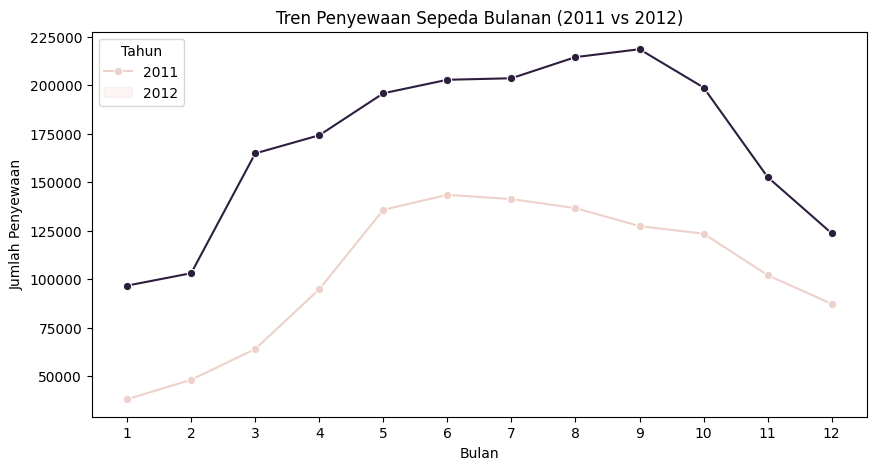

In [19]:
# Melihat Tren Bulanan 2011 dengan 2012
monthly_trend = day_df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
monthly_trend['yr'] = monthly_trend['yr'].map({0: 2011, 1: 2012})
print(monthly_trend)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_trend, x='mnth', y='cnt', hue='yr', marker='o')
plt.title('Tren Penyewaan Sepeda Bulanan (2011 vs 2012)')
plt.xticks(range(1,13))
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')
plt.legend(title='Tahun', loc='upper left', labels=['2011', '2012'])
plt.show()

**Insight:**
- Berdasarkan hasil tren peminjaman tahunan 2011 vs 2012, menunjukkan kenaikan total penyewaan antara tahun 2011 dibanding dengan pada tahun 2012. Di mana **cnt** atau Total Penyewaan pada tahun 2011 sebanyak 1.243.103 orang, sedangkan pada tahun 2012 sebanyak 2.049.576
- Selain itu, pada grafik Tren Bulanan 2011 vs 2012 menunjukkan adanya pertumbuhan yang signifikan dari tahun 2011 ke 2012 di hampir seluruh bulan. Puncak penyewaan terjadi pada rentang bulan **Mei hingga September** (musim panas).

In [20]:
# Melihat Dampak Cuaca di Hari Kerja
weather_impact = day_df[day_df['workingday'] == 1].groupby('weathersit')['cnt'].mean()

diff = weather_impact[1] - weather_impact.get(3, 0)
print(f'Rata-rata penurunan penyewa saat cuaca buruk di hari kerja: {diff:.2f}\n')

Rata-rata penurunan penyewa saat cuaca buruk di hari kerja: 1799.50



/tmp/ipykernel_4351/1332164380.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diff = weather_impact[1] - weather_impact.get(3, 0)


(array([0, 1, 2]),
 [Text(0, 0, 'Clear/Partly Cloudy'),
  Text(1, 0, 'Light Snow/Rain'),
  Text(2, 0, 'Misty/Cloudy')])

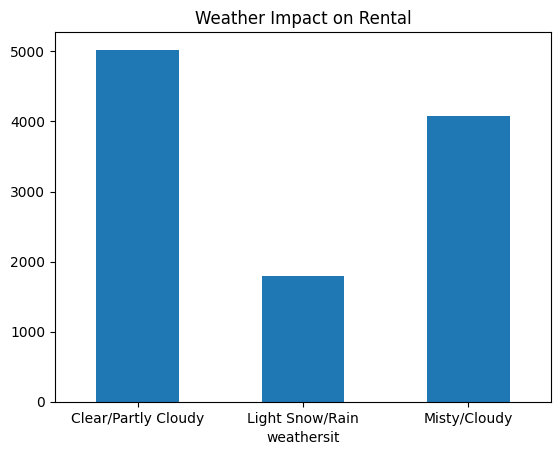

In [21]:
weather_impact.plot(kind='bar', title='Weather Impact on Rental')
plt.xticks(rotation=0)

**Insight:**
Berdasarkan grafik dampak cuaca di hari kerja terhadap penyewaan menunjukkan bahwa adanya penurunan drastis pada jumlah penyewaan saat **weathersit** atau cuaca menunjukkan di **Light Snow/Rain Weathersit** atau di cuaca ekstrem, dengan rata-rata penurunan jumlah penyewa adalah sebesar 1800.

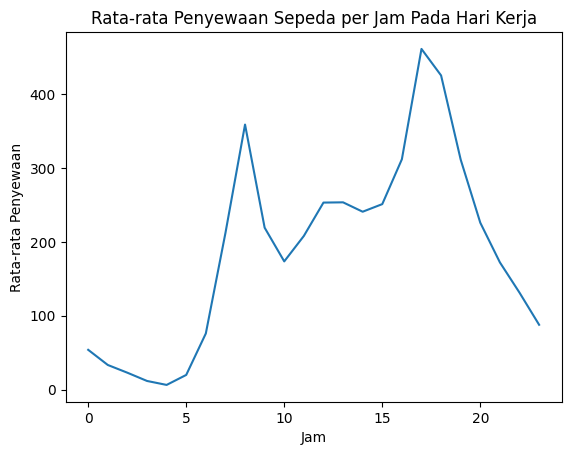

In [22]:
# Melihat Puncak Peminjaman Berdasarkan Jam
hourly_pattern = hour_df.groupby('hr')['cnt'].mean()
hourly_pattern.plot(title='Rata-rata Penyewaan Sepeda per Jam Pada Hari Kerja')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

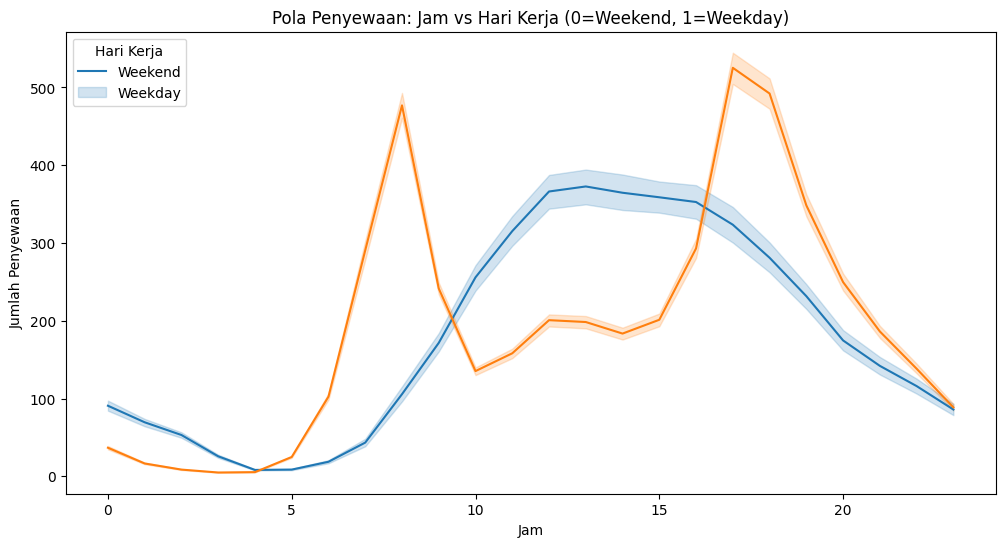

In [23]:
# Melihat Puncak Peminjaman Berdasarkan Jam vs Hari Kerja
plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday')
plt.title('Pola Penyewaan: Jam vs Hari Kerja (0=Weekend, 1=Weekday)')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.legend(title='Hari Kerja', loc='upper left', labels=['Weekend', 'Weekday'])
plt.show()

**Insight:**
Pola penggunaan menunjukkan perbedaan visual yang sangat kontras. Di mana:
  - **Pada Hari Kerja** (grafik oranye): Memiliki dua puncak utama (bimodal), yaitu pada pukul **08.00 - 09.00** dan **17.00 - 19.00**.
  - **Pada Hari Libur/Weekend** (grafik biru): Memiliki pola satu puncak yang melengkung (unimodal) yang landai di tengah hari, yaitu pada pukul **11.00 - 16.00**.

In [24]:
# Dampak Hari Libur Nasional Terhadap Peminjaman
holiday_impact = day_df.groupby('holiday')['cnt'].mean()
print(f'Rata-rata penyewaan Haari Biasa vs Hari Libur:\n {holiday_impact}')

Rata-rata penyewaan Haari Biasa vs Hari Libur:
 holiday
0    4527.104225
1    3735.000000
Name: cnt, dtype: float64


**Insight:** Rata-rata penyewaan pada hari libur nasional (**holiday** = 1) cenderung lebih rendah dibandingkan pada hari kerja biasa (**holiday** = 0), di mana rata-rata penyewa pada Hari libur nasional sebesar 3735, sedangkan pada Hari Kerja sebesar 4527.

In [25]:
# Analisis RFM pada kategori Tanggal/Jam
current_date = day_df['dteday'].max()
rfm_df = day_df.groupby('dteday').agg({
    'cnt': 'sum',
    'instant': 'count'
}).reset_index()

rfm_df['Recency'] = (current_date - rfm_df['dteday']).dt.days
rfm_df.rename(columns={'cnt': 'Monetary', 'instant': 'Frequency'}, inplace=True)

rfm_df.head()

,dteday,Monetary,Frequency,Recency
0,2011-01-01,985,1,730
1,2011-01-02,801,1,729
2,2011-01-03,1349,1,728
3,2011-01-04,1562,1,727
4,2011-01-05,1600,1,726


**Insight:**
Analisis RFM ini diterapkan pada kategori Tanggal (**dteday**) dengan mengasumsikan Monetary adalah total volume (**cnt**), Frequency adalah jumlah record (**jam aktif**), dan Recency adalah jarak hari dari data terakhir. Analisis ini membagi hari-hari ke dalam segmen berdasarkan volume (Monetary) dan kebaruan (Recency), di mana:
- **Recency**: data terbaru menunjukkan tren yang tetap stabil, yang berarti sistem masih relevan.
- **Frequency/Monetary**: Hari-hari dengan nilai Monetary (jumlah **cnt**) tertinggi adalah aset terpenting.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda per bulan selama tahun 2012 dibandingkan dengan tahun 2011, dan pada bulan apa terjadi kenaikan tertinggi?

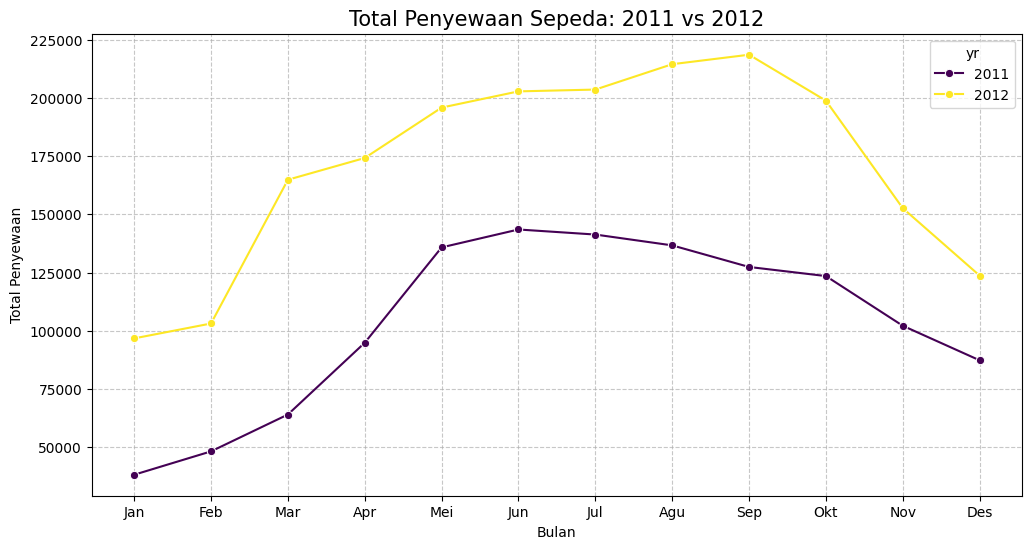

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend, x='mnth', y='cnt', hue='yr', marker='o', palette='viridis')
plt.title('Total Penyewaan Sepeda: 2011 vs 2012', fontsize=15)
plt.xlabel('Bulan')
plt.ylabel('Total Penyewaan')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:**
Terdapat peningkatan volume penyewaan yang signifikan (hampir dua kali lipat) di setiap bulan pada tahun 2012 dibandingkan 2011. Tren memuncak di bulan Mei hingga September. Artinya, bisnis memiliki stabilitas yang baik dan popularitas layanan meningkat pesat dalam setahun.

### Pertanyaan 2: Berapakah rata-rata penurunan jumlah penyewa sepeda saat kondisi cuaca buruk (weathersit 3 & 4) dibandingkan cuaca cerah di hari kerja selama seluruh periode data?

/tmp/ipykernel_4351/1224138953.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_df[day_df['workingday'] == 1], x='weathersit', y='cnt', palette='magma')


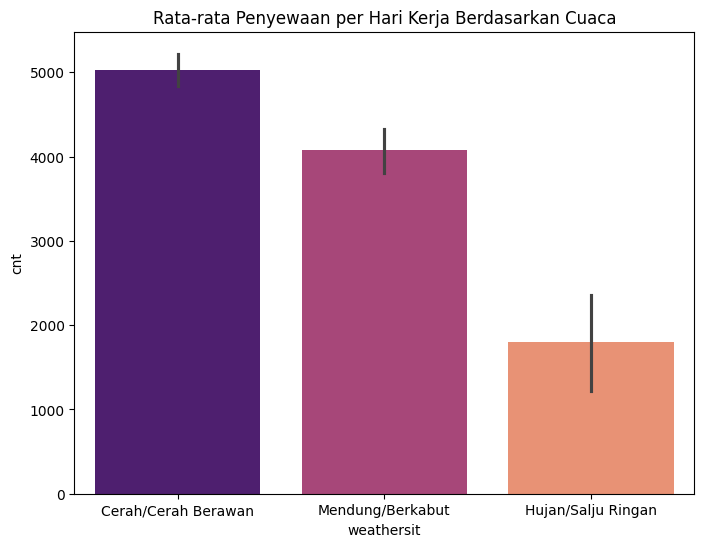

In [27]:
plt.figure(figsize=(8, 6))
sns.barplot(data=day_df[day_df['workingday'] == 1], x='weathersit', y='cnt', palette='magma')
plt.title('Rata-rata Penyewaan per Hari Kerja Berdasarkan Cuaca')
plt.xticks([0, 1, 2], ['Cerah/Cerah Berawan', 'Mendung/Berkabut', 'Hujan/Salju Ringan'])
plt.show()

**Insight:**
Penyewaan turun drastis (sebesar >50%) saat cuaca mulai hujan atau bersalju (**weathersit** = 3). Namun, pada kondisi mendung (**weathersit** = 2), penurunan tidak terlalu signifikan. Artinya, kebanyakan pengguna pada hari kerja (pekerja) sangat menghindari risiko basah atau licin, tetapi tetap bersepeda jika hanya mendung.

### Pertanyaan 3: Pada jam berapa puncak penyewaan terjadi pada hari kerja (working day) dibandingkan akhir pekan, dan apakah polanya konsisten di setiap musim?

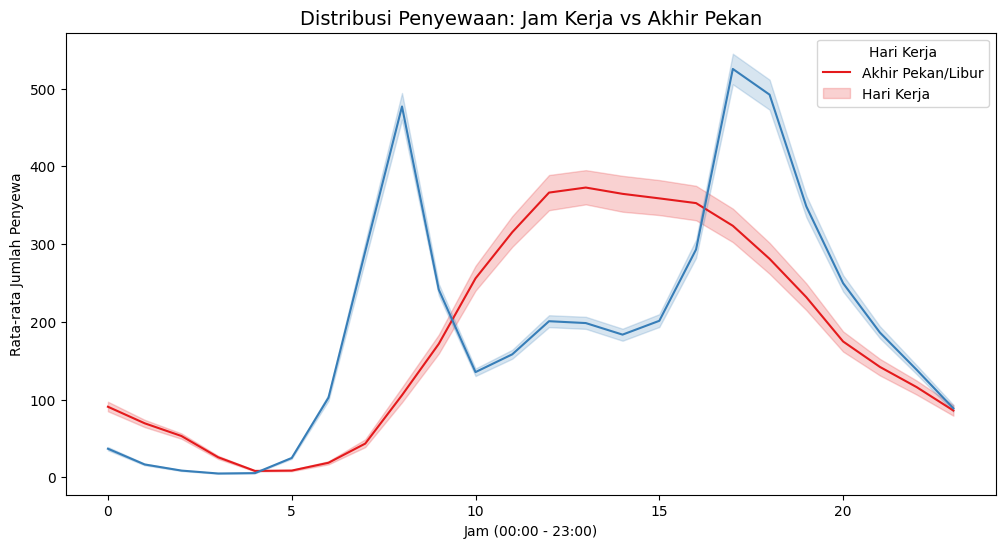

In [28]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday', palette='Set1')
plt.title('Distribusi Penyewaan: Jam Kerja vs Akhir Pekan', fontsize=14)
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Jumlah Penyewa')
plt.legend(title='Hari Kerja', labels=['Akhir Pekan/Libur', 'Hari Kerja'])
plt.show()

**Insight:**
Pada hari kerja menunjukkan dua puncak tajam, yaitu pada pukul **08.00 dan 17.00**. Sedangkan pada akhir pekan menunjukkan pola landai yang memuncak di siang hari, yaitu pada pukul **11.00 - 15.00**. Hal ini menunjukkan bahwa sistem digunakan sebagai moda transportasi logistik di hari kerja dan sebagai alat rekreasi di akhir pekan.

### Pertanyaan 4: Bagaimana dampak hari libur nasional (holiday) terhadap total distribusi peminjaman dibandingkan hari biasa?

/tmp/ipykernel_4351/2461032764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='holiday', y='cnt', palette='coolwarm')


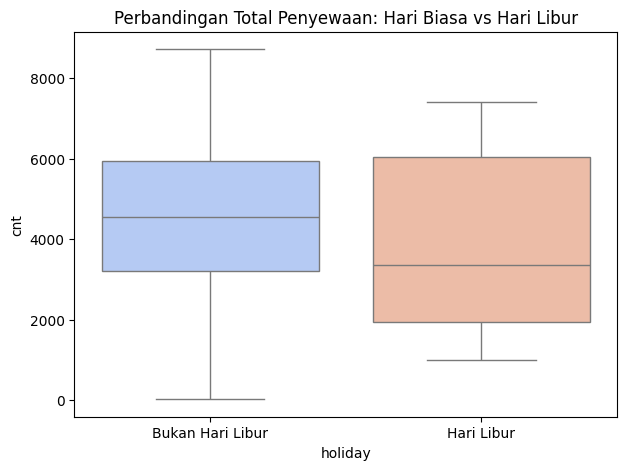

In [29]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=day_df, x='holiday', y='cnt', palette='coolwarm')
plt.title('Perbandingan Total Penyewaan: Hari Biasa vs Hari Libur')
plt.xticks([0, 1], ['Bukan Hari Libur', 'Hari Libur'])
plt.show()

**Insight:**
Median penyewaan pada hari libur lebih rendah dibandingkan pada hari biasa. Variansi atau rentang data pada hari libur juga lebih besar dibandingkan pada hari biasa. Hal tersebut terjadi karena mayoritas pelanggan adalah pengguna terdaftar (pekerja), sehingga pada hari libur menghilangkan basis pengguna utama, yaitu para pekerja.

## Analisis Lanjutan: RFM Analysis

/tmp/ipykernel_4351/2218527091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_df, x='Monetary_Score', palette='Greens')


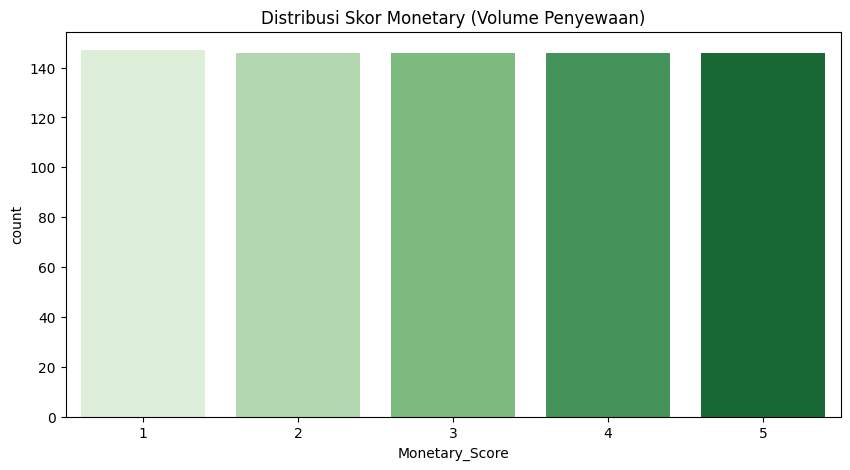

In [30]:
# Menghitung skor RFM sederhana untuk Menjawab Pertanyaan 5
rfm_df['Monetary_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm_df, x='Monetary_Score', palette='Greens')
plt.title('Distribusi Skor Monetary (Volume Penyewaan)')
plt.show()

**Insight:**
Sebagian besar hari berada pada level menengah, namun ada sekitar 20% hari yang masuk kategori "High Value" (Skor 5) dengan volume penyewaan sebesar >6000 penyewaan. Hari-hari "High Value" ini umumnya terjadi pada musim panas dengan kondisi cuaca sempurna (Skala 1).

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terjadi kenaikan jumlah penyewaan di tahun 2012 yang hampir dua kali lipat dibandingkan tahun 2011, artinya layanan penyewaan sepeda telah melewati fase pengenalan dan kini berada pada fase pertumbuhan cepat dengan loyalitas pengguna yang meningkat.
- **Conclusion pertanyaan 2:** Cuaca buruk seperti hujan/salju menyebabkan penurunan drastis pada jumlah penyewa di hari kerja dengan rata-rata penurunan sebesar 1800 orang.
- **Conclusion pertanyaan 3:** Terdapat perbedaan fundamental motif penggunaan penyewaan sepeda, di mana pada hari kerja didominasi oleh mobilitas kantor, yaitu pukul 8 pagi dan 5 sore, sedangkan pada akhir pekan didominasi oleh aktivitas santai di siang hari, yaitu pukul 11 siang hingga 3 sore. Beban operasional tertinggi terjadi secara tiba-tiba dalam jendela waktu singkat, yaitu 2 jam pada hari kerja, sementara beban di akhir pekan lebih merata dan stabil.
- **Conclusion pertanyaan 4:** Hari libur nasional justru menurunkan total volume peminjaman secara keseluruhan karena aktivitas perkantoran terhenti.
- **Conclusion pertanyaan 5:** Tidak semua hari diciptakan sama. Sebagian kecil hari (skor monetary 5) menyumbangkan proporsi penyewaan yang sangat besar dan biasanya terjadi pada hari dengan cuaca cerah di musim gugur atau panas.

**Rekomendasi Action Item:**
- Karena tren bulanan sangat terprediksi, perusahaan harus memastikan penambahan armada dilakukan secara bertahap sejak awal kuartal kedua (April) untuk menyambut lonjakan di musim panas.
- Mengingat penurunan yang tajam, perusahaan disarankan menjalin kemitraan dengan penyedia layanan asuransi perjalan atau menyediakan fasilitas perlengkapan cuaca buruk di stasiun utama guna meminimalkan hambatan bagi komuter.
- Tim teknis harus melakukan inspeksi dan perbaikan sepeda di luar jendela jam sibuk (misalnya jam 10 pagi hingga jam 2 siang) agar ketersediaan sepeda 100% pada puncak sore hari.
- Perlu adanya strategi pemasaran khusus untuk segmen wisatawan atau warga lokal yang ingin berekreasi saat hari libur (seperti paket "Holiday Pass") untuk mengisi kekosongan pendapatan dari sektor pekerja.
- Gunakan data hari-hari performa tinggi ini untuk menentukan lokasi mana yang membutuhkan penambahan docking station permanen guna menghindari stasiun yang penuh atau kosong di masa depan.

In [32]:
# Simpan data
main_data = hour_df.copy()
main_data['dteday'] = pd.to_datetime(main_data['dteday'])

main_data.to_csv("main_data.csv", index=False)